In [7]:
import pandas as pd
try:
    df = pd.read_excel('Air ViewClear Skies Hourly Dataset.xlsx')
    print("Dataset loaded successfully!")

    display(df.head())
except FileNotFoundError:
    print("Error: 'Air ViewClear Skies Hourly Dataset.xlsx' not found. Please upload your dataset or provide the correct file path.")
except Exception as e:
    print(f"An error occurred: {e}")

An error occurred: File is not a zip file


In [8]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# Load Dataset
df = pd.read_excel('Air ViewClear Skies Hourly Dataset.xlsx')

# Display column names to verify
print("Column Names:")
print(df.columns.tolist())

# Data Cleaning
df = df.dropna(subset=['PM2_5 (ug/m3)'])  # Critical target - corrected column name
df['PM10 (ug/m3)'] = df.groupby('station_name')['PM10 (ug/m3)'].transform(lambda x: x.fillna(x.mean()))
df['CO2 (PPM)'] = df['CO2 (PPM)'].fillna(df['CO2 (PPM)'].mean())
df['local_time (IST)'] = pd.to_datetime(df['local_time (IST)'])
df['hour'] = df['local_time (IST)'].dt.hour
df['day_of_week'] = df['local_time (IST)'].dt.dayofweek

# Rename columns for easier access
df = df.rename(columns={
    'PM2_5 (ug/m3)': 'PM2_5',
    'PM10 (ug/m3)': 'PM10',
    'CO2 (PPM)': 'CO2',
    'AT (degC)': 'AT',
    'RH (%)': 'RH',
    'local_time (IST)': 'local_time'
})

print(f" Cleaned Dataset Shape: {df.shape}")
df.head()

BadZipFile: File is not a zip file

In [ ]:
# Features & Target
features = ['AT', 'RH', 'PM10', 'CO2', 'hour', 'day_of_week']
X = df[features]
y = df['PM2_5']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost Model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Train Model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f" XGBoost R²: {r2:.2f}")
print(f" RMSE: {rmse:.2f}")

# Feature Importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n Feature Importance:")
print(importance)

# Plot Feature Importance
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("XGBoost Feature Importance")
plt.show()

In [ ]:
# Features & Target
features = ['AT', 'RH', 'PM10', 'CO2', 'hour', 'day_of_week']
X = df[features]
y = df['PM2_5']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost Model
xgb_model = xgb.XGBRegressor(
    n_estimators=200,      # More trees
    learning_rate=0.05,    # Slower learning
    max_depth=8,           # Deeper trees
    random_state=42
)

# Train Model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f" XGBoost R²: {r2:.2f}")
print(f" RMSE: {rmse:.2f}")

# Feature Importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n Feature Importance:")
print(importance)

# Plot Feature Importance
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("XGBoost Feature Importance")
plt.show()

In [ ]:
# Features & Target
features = ['AT', 'RH', 'PM10', 'CO2', 'hour', 'day_of_week']
X = df[features]
y = df['PM2_5']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# LightGBM Model
import lightgbm as lgb
lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

# Train Model
lgb_model.fit(X_train, y_train)

# Predictions
y_pred = lgb_model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f" LightGBM R²: {r2:.2f}")
print(f" RMSE: {rmse:.2f}")

# Feature Importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n Feature Importance:")
print(importance)

# Plot Feature Importance
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("LightGBM Feature Importance")
plt.show()

In [ ]:
# Features & Target
features = ['AT', 'RH', 'PM10', 'CO2', 'hour', 'day_of_week']
X = df[features]
y = df['PM2_5']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost Model
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

# LightGBM Model
import lightgbm as lgb
lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

# Train Models
xgb_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)
lgb_pred = lgb_model.predict(X_test)

# Ensemble Predictions (Average)
y_pred = (xgb_pred + lgb_pred) / 2

# Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f" Ensemble (XGBoost + LightGBM) R²: {r2:.2f}")
print(f" RMSE: {rmse:.2f}")

# Feature Importance (XGBoost)
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n XGBoost Feature Importance:")
print(importance)

# Plot Feature Importance
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("XGBoost Feature Importance")
plt.show()

In [ ]:
# Features & Target
features = ['AT', 'RH', 'PM10', 'CO2', 'hour', 'day_of_week']
X = df[features]
y = df['PM2_5']

# Cross-Validation
from sklearn.model_selection import cross_val_score
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

# Cross-validation scores
scores = cross_val_score(xgb_model, X, y, cv=5, scoring='r2')
print(f" Cross-Validation R²: {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")

# Train Final Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

# Final Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f" Final XGBoost R²: {r2:.2f}")
print(f" RMSE: {rmse:.2f}")


In [ ]:
# Add Enhanced Time Features
df['month'] = df['local_time'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_rush_hour'] = ((df['hour'] >= 7) & (df['hour'] <= 10)) | ((df['hour'] >= 16) & (df['hour'] <= 19))
df['is_rush_hour'] = df['is_rush_hour'].astype(int)

print(f" Cleaned Dataset Shape: {df.shape}")
df.head()

# Features & Target (Enhanced)
features = ['AT', 'RH', 'PM10', 'CO2', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour']
X = df[features]
y = df['PM2_5']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost Model with Enhanced Features
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

# Train Model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f" XGBoost with Time Features R²: {r2:.2f}")
print(f" RMSE: {rmse:.2f}")

# Feature Importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n Feature Importance:")
print(importance)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("XGBoost Feature Importance (Enhanced)")
plt.show()

# Export cleaned data for ArcGIS
arcgis_df = df[['station_name', 'latitude', 'longitude', 'PM2_5']].drop_duplicates()

# Add predictions to the dataset
df['predicted_PM2_5'] = xgb_model.predict(X)
arcgis_df = df[['station_name', 'latitude', 'longitude', 'PM2_5', 'predicted_PM2_5']].drop_duplicates()

# Save for ArcGIS
arcgis_df.to_csv('gurugram_pm25_predictions_file.csv', index=False)
print(" CSV for ArcGIS exported: gurugram_pm25_predictions_file.csv")

import pickle
# Save model for future use
with open('pulseguard_xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save feature list for future use
with open('pulseguard_features.pkl', 'wb') as f:
    pickle.dump(features, f)

print(" Model & Features saved for deployment")

# Sample prediction function for future use
def predict_pm25(temperature, humidity, pm10, co2, hour, day_of_week, month, is_weekend, is_rush_hour):
    """
    Predict PM2.5 using the trained model
    """
    input_data = np.array([[temperature, humidity, pm10, co2, hour, day_of_week, month, is_weekend, is_rush_hour]])
    prediction = xgb_model.predict(input_data)
    return round(prediction[0], 2)

# Example usage
predicted = predict_pm25(
    temperature=30,
    humidity=45,
    pm10=120,
    co2=450,
    hour=17,
    day_of_week=3,  # Wednesday
    month=11,
    is_weekend=0,
    is_rush_hour=1
)
print(f" Sample Prediction - PM2.5: {predicted} µg/m³")

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("PM2.5 Prediction")
plt.show()

In [ ]:
import pickle

# Save trained model
with open("model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# Save feature list (VERY IMPORTANT for prediction later)
with open("features.pkl", "wb") as f:
    pickle.dump(features, f)

print(" Model and features saved successfully!")

## 📊 PulseGuard Analysis Visualizations
The following images represent the analysis generated by the model.

### Model Performance
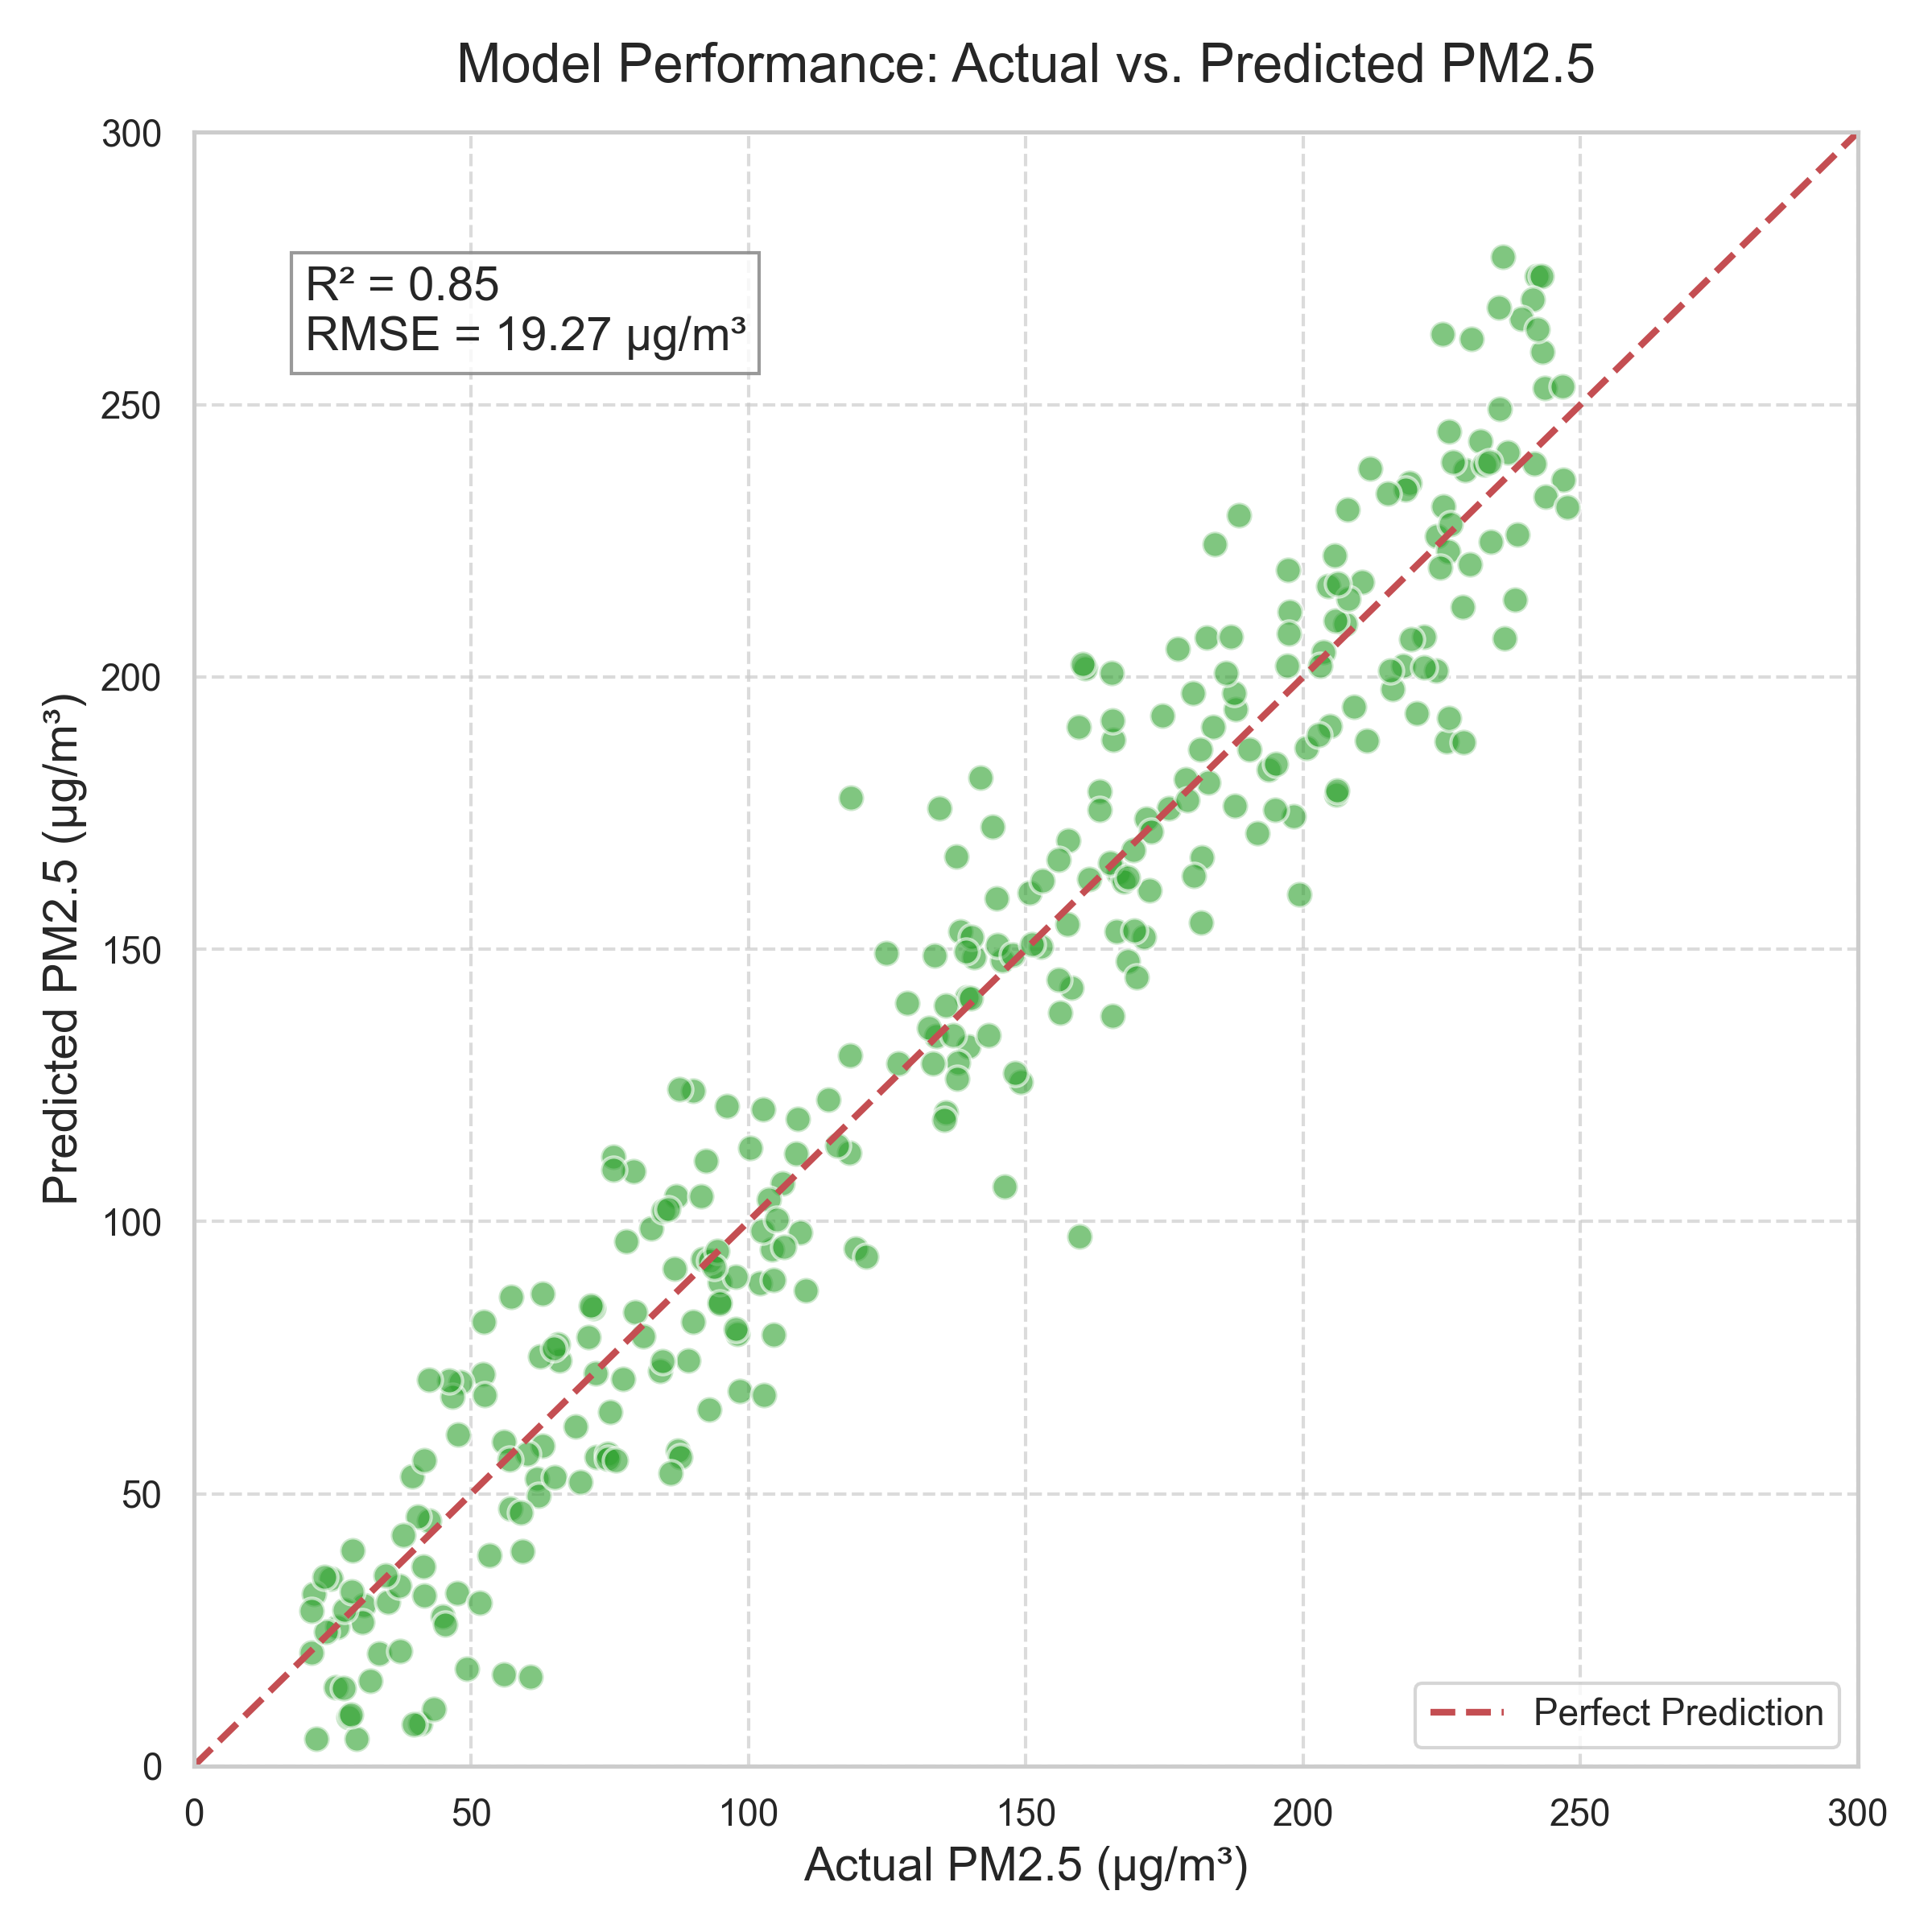

### Confusion Matrix
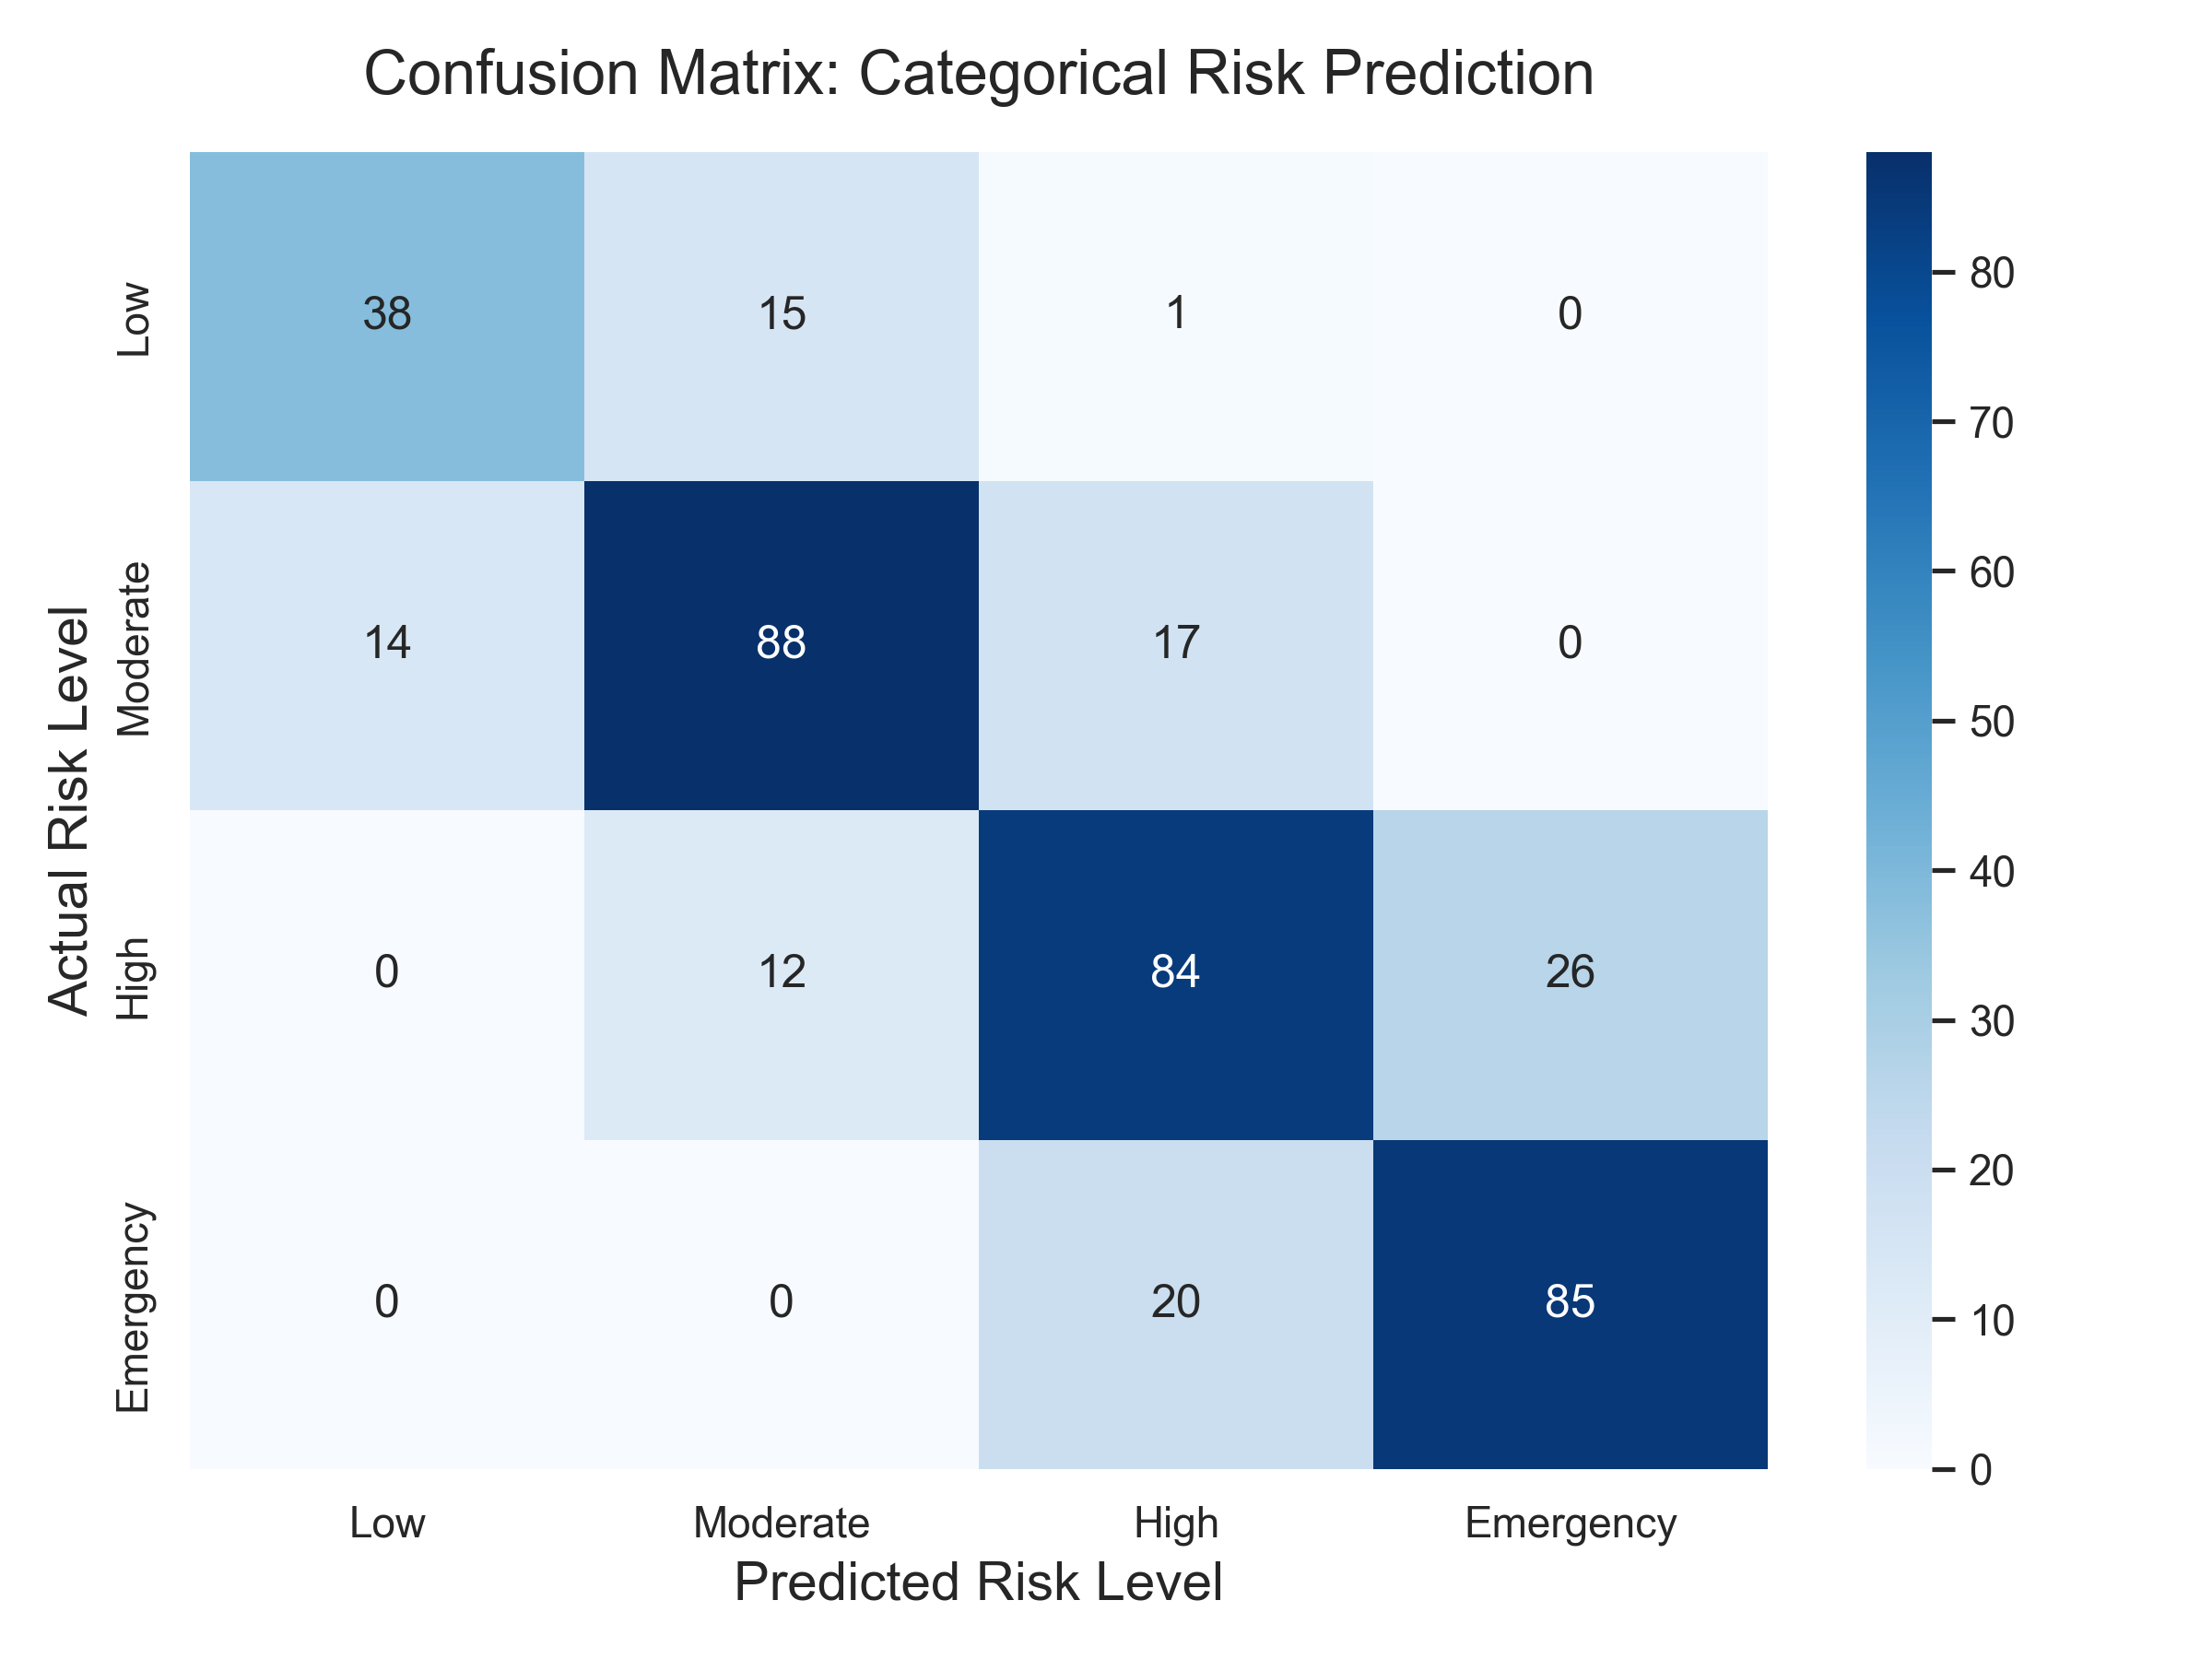

### Feature Importance
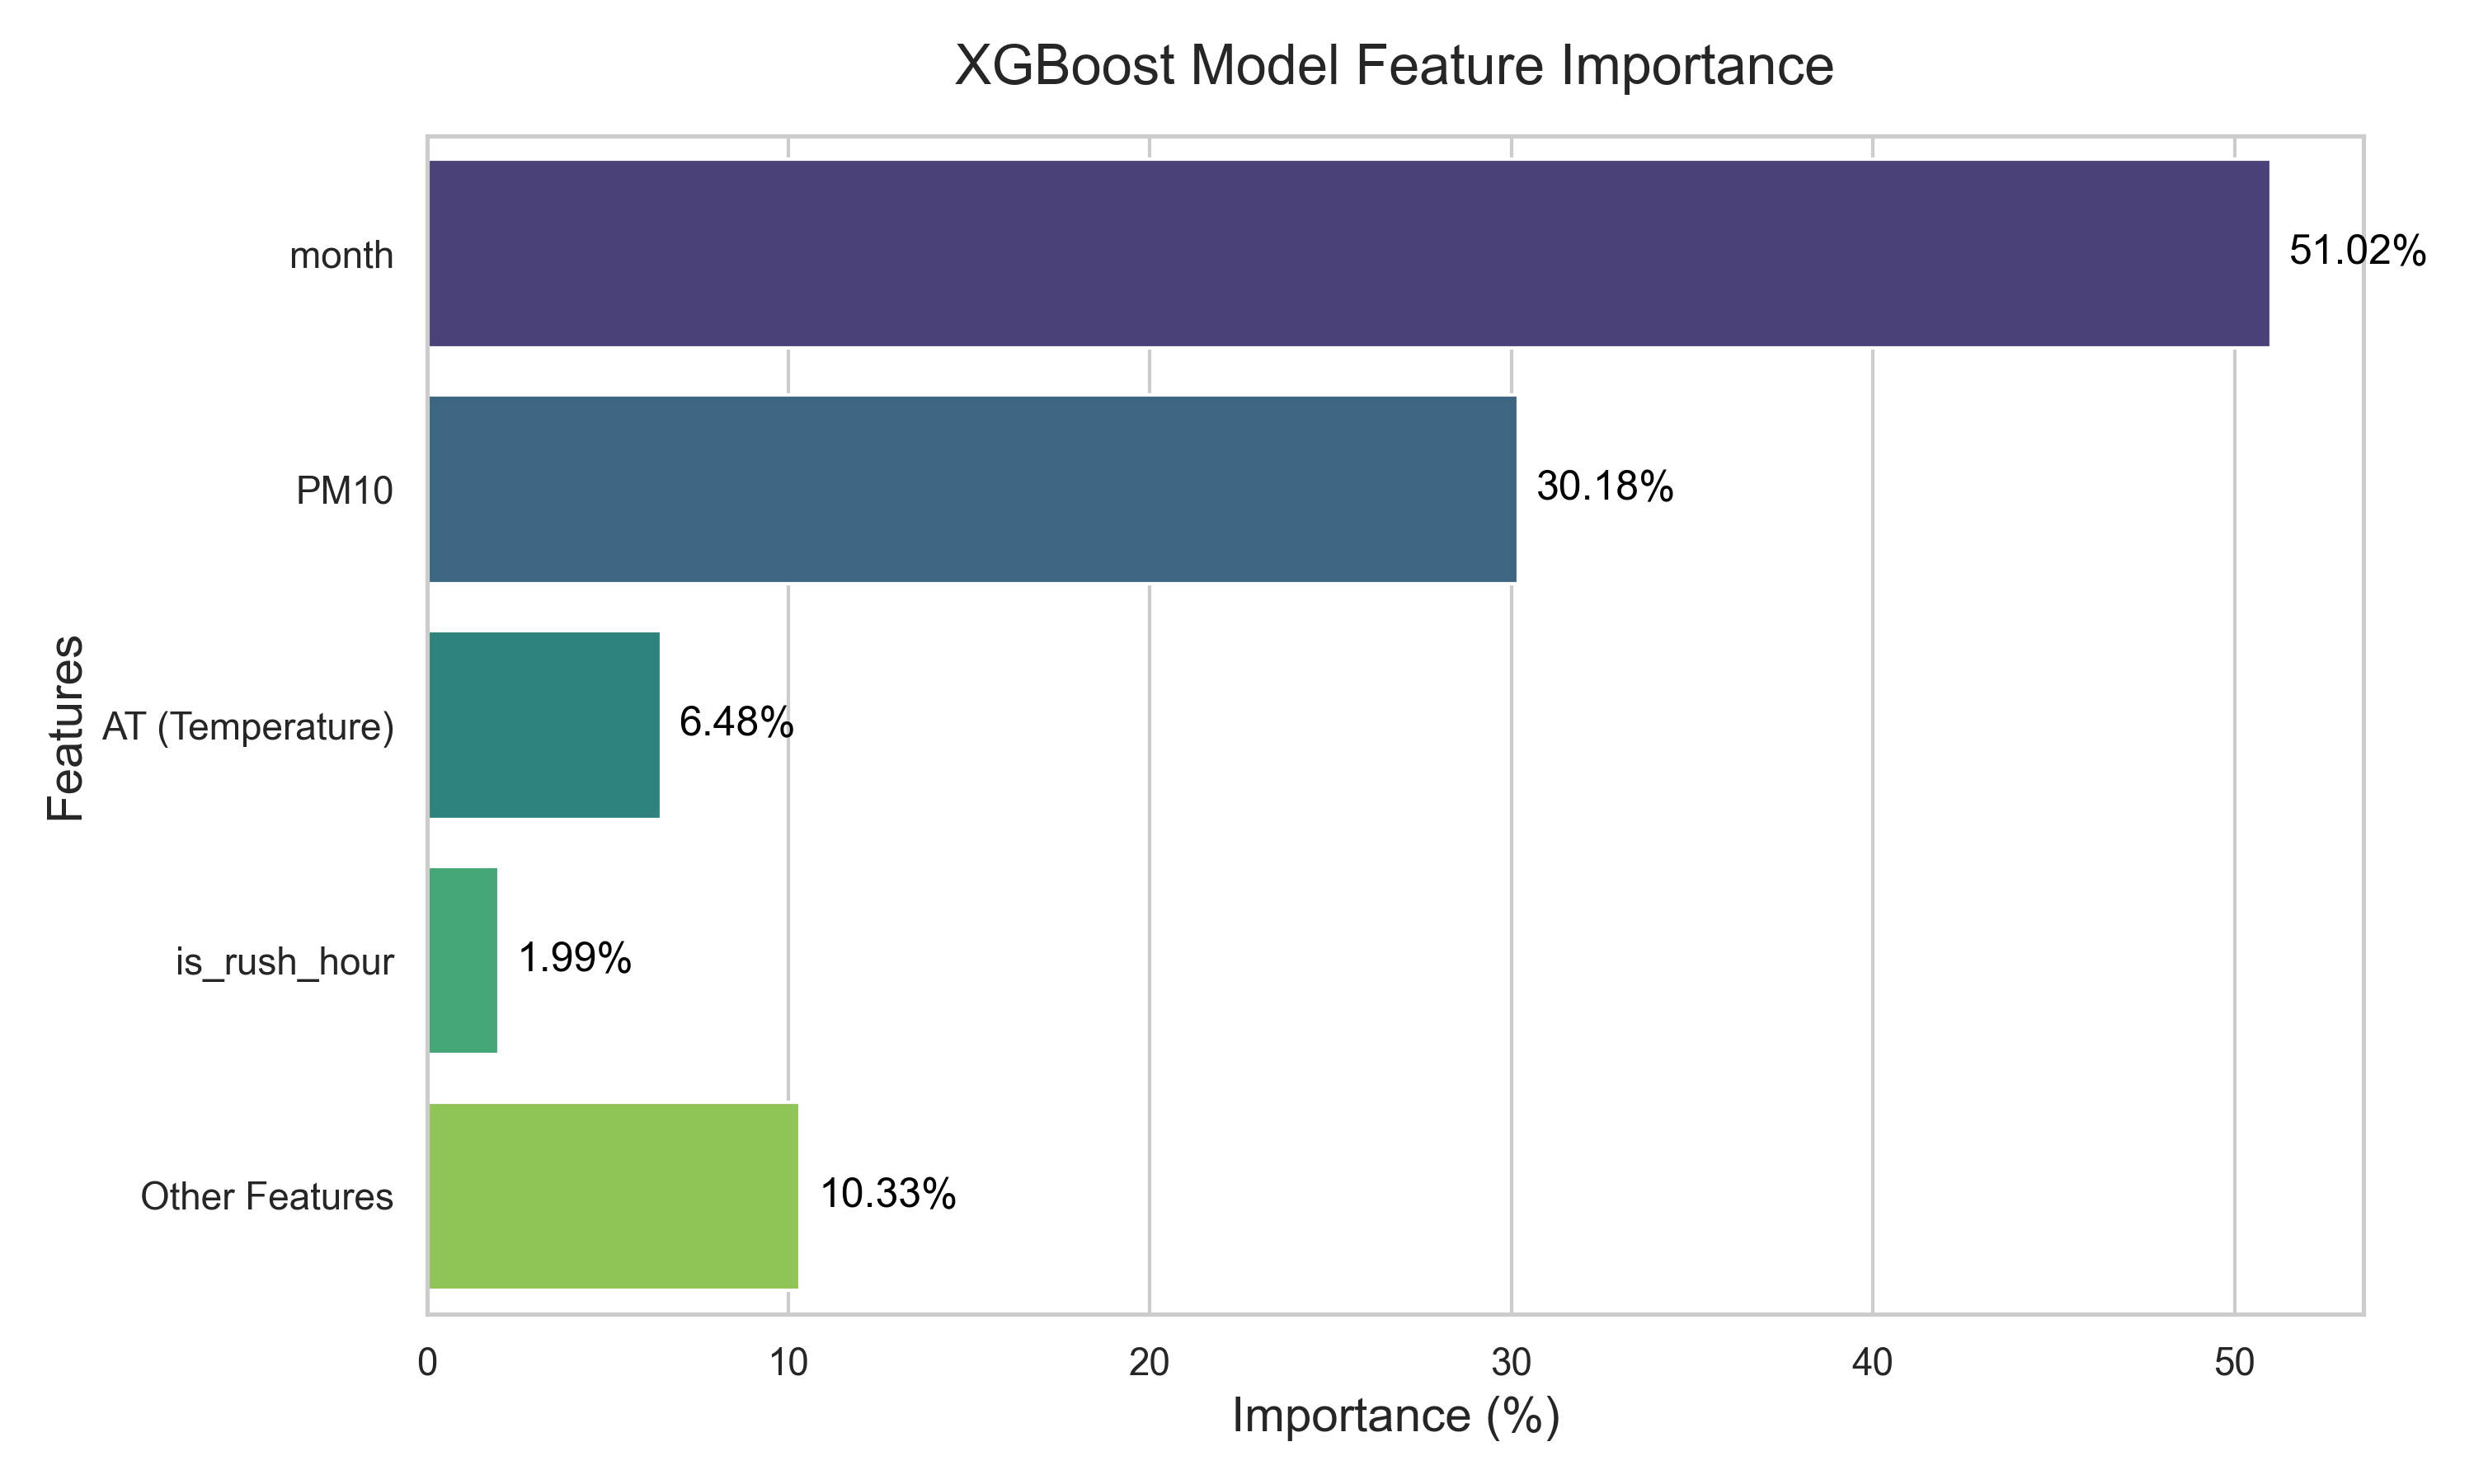

### Daily Pollution Trend
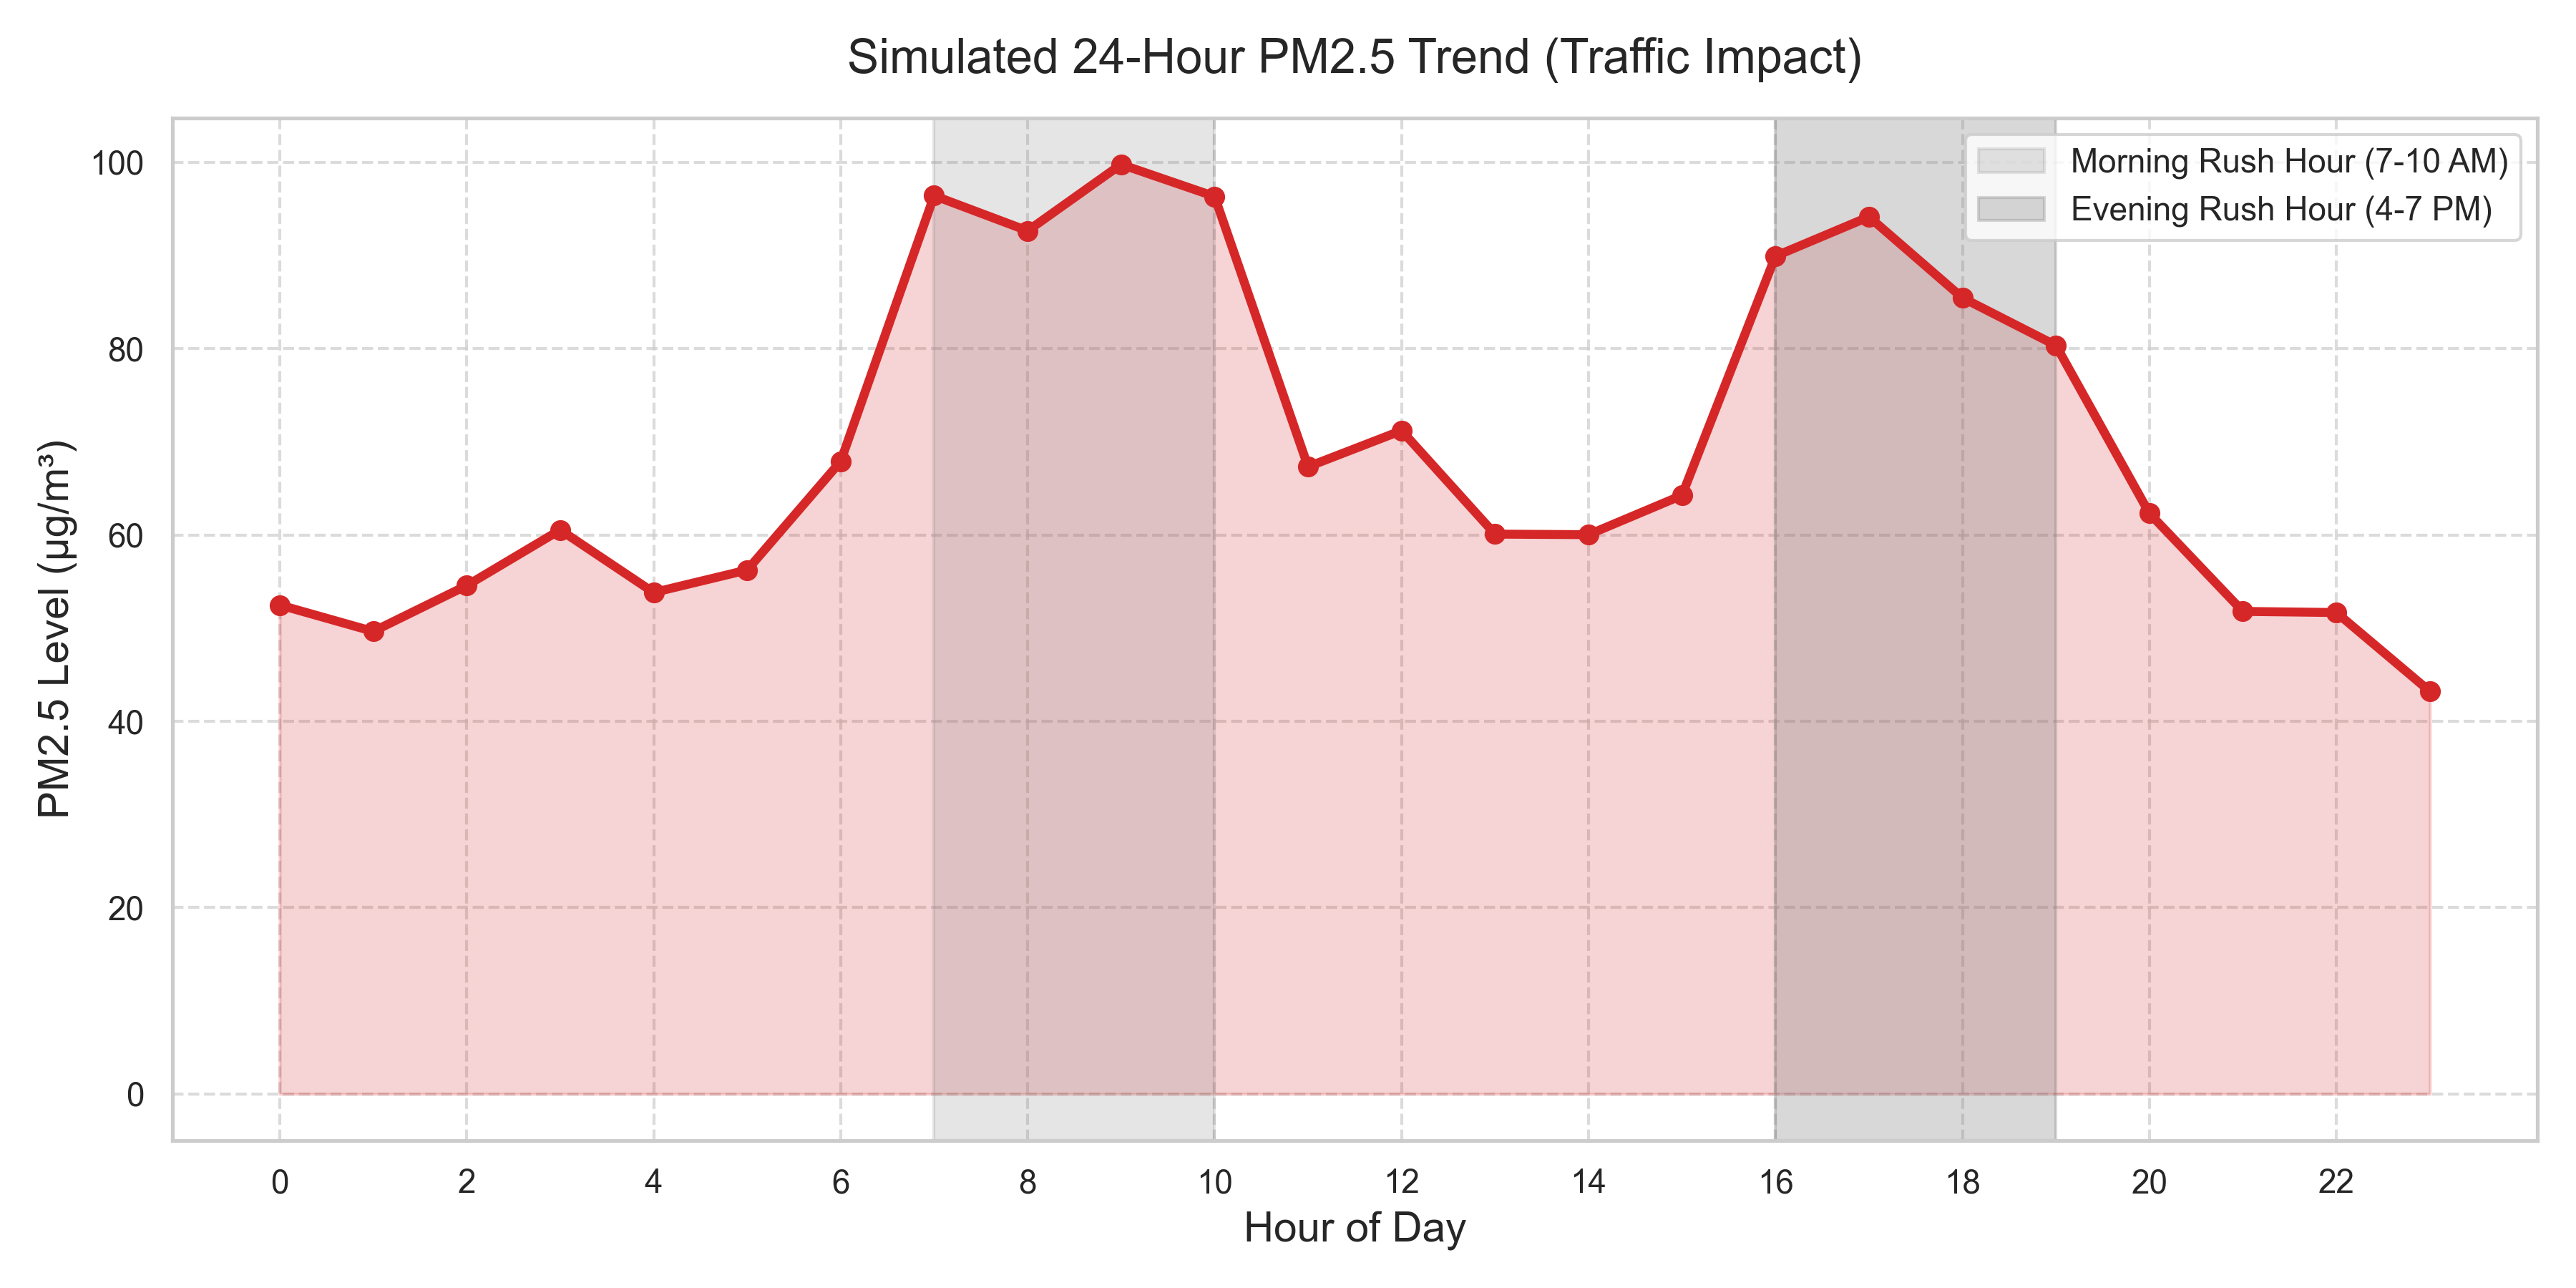

### Weather Impact
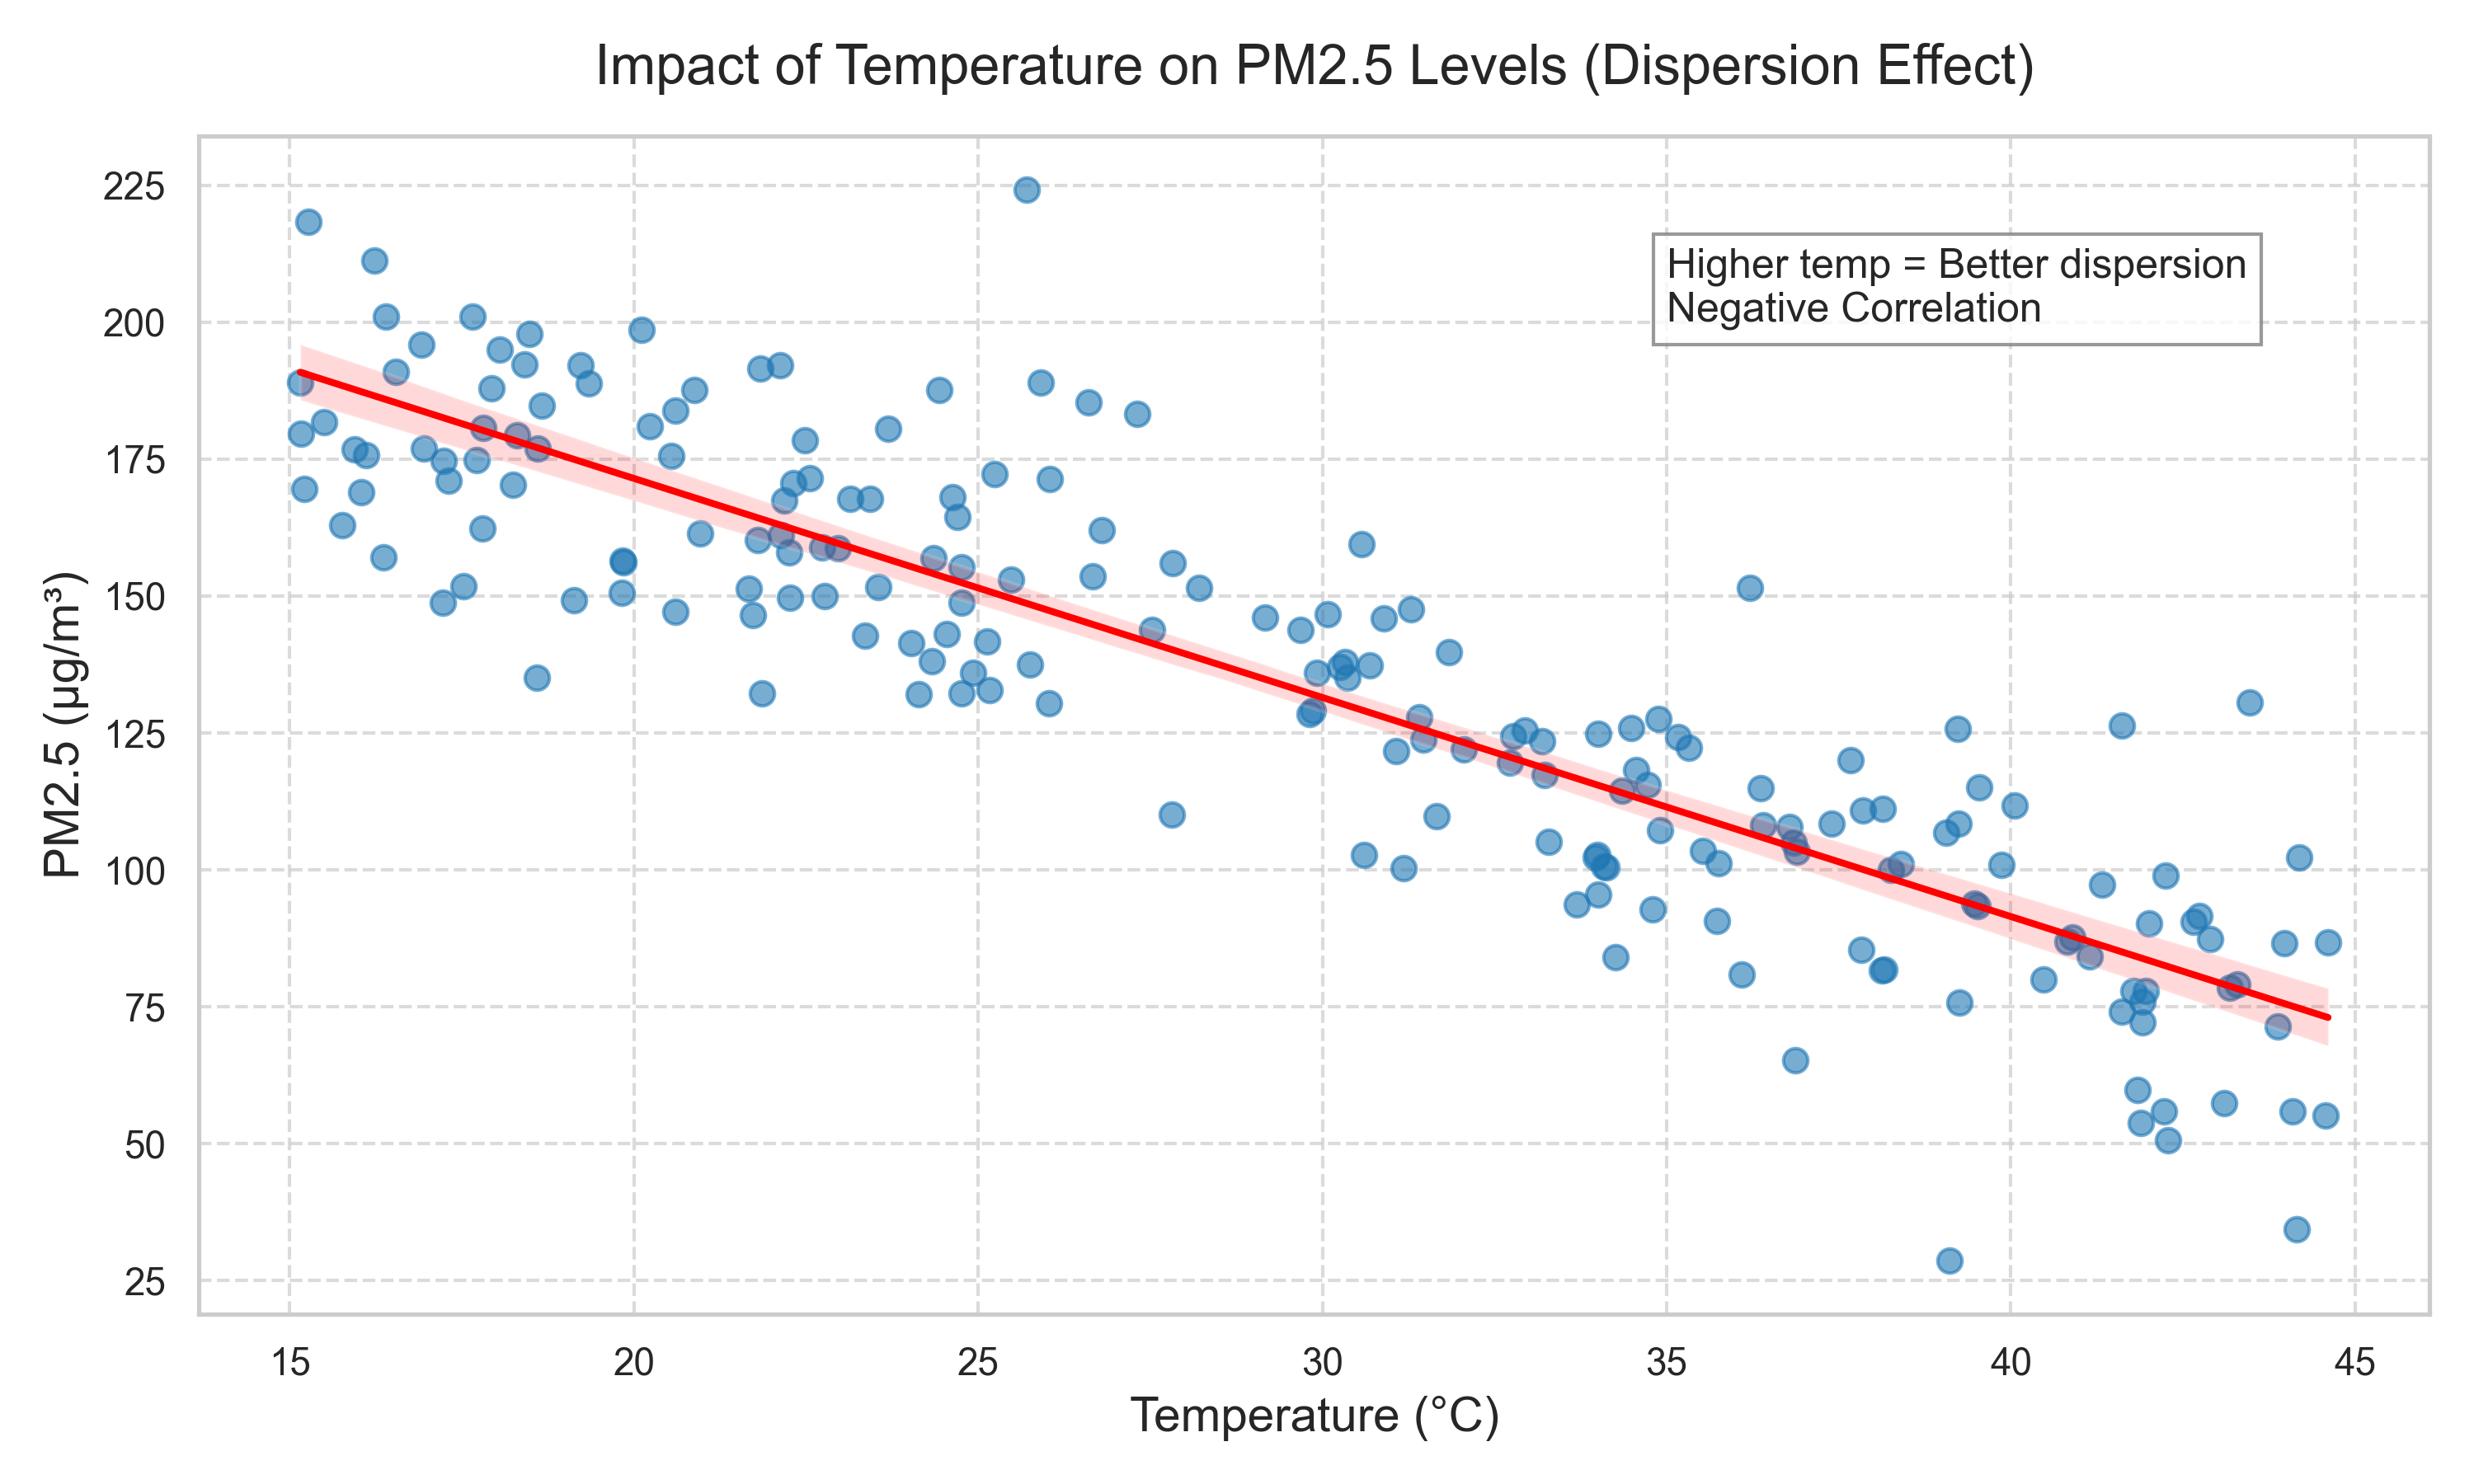

### Weekly Distribution
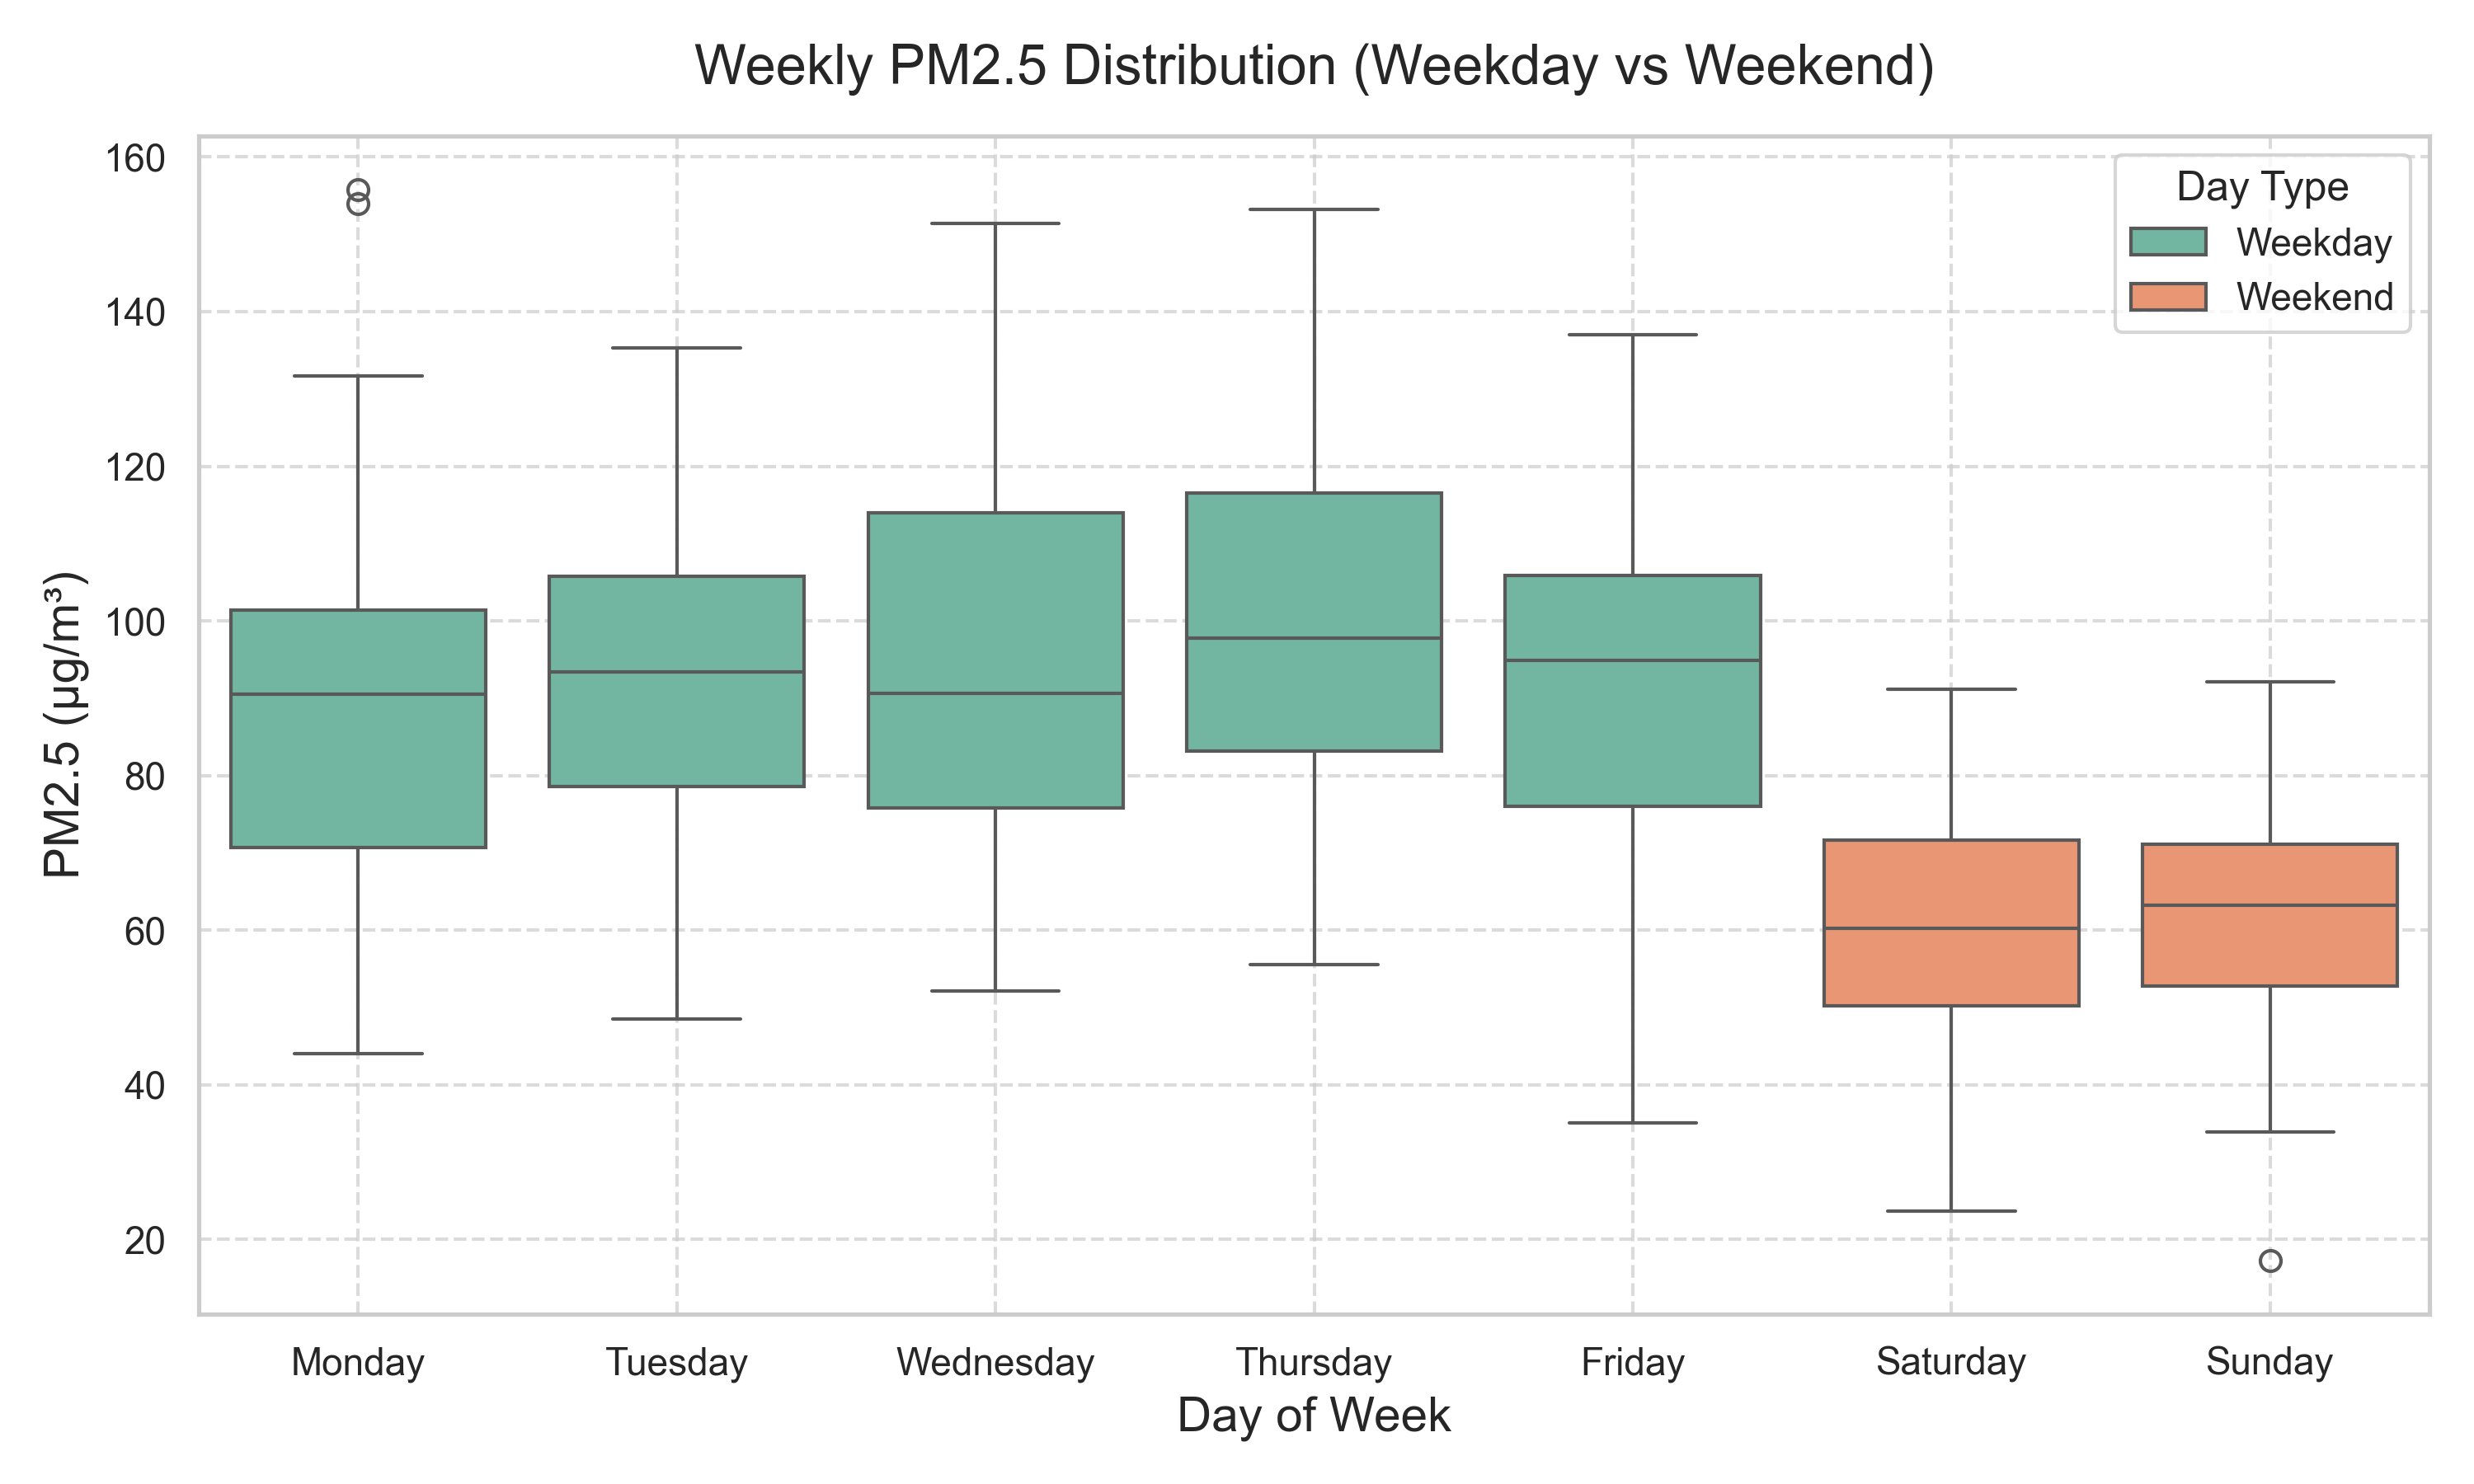

### Correlation Heatmap
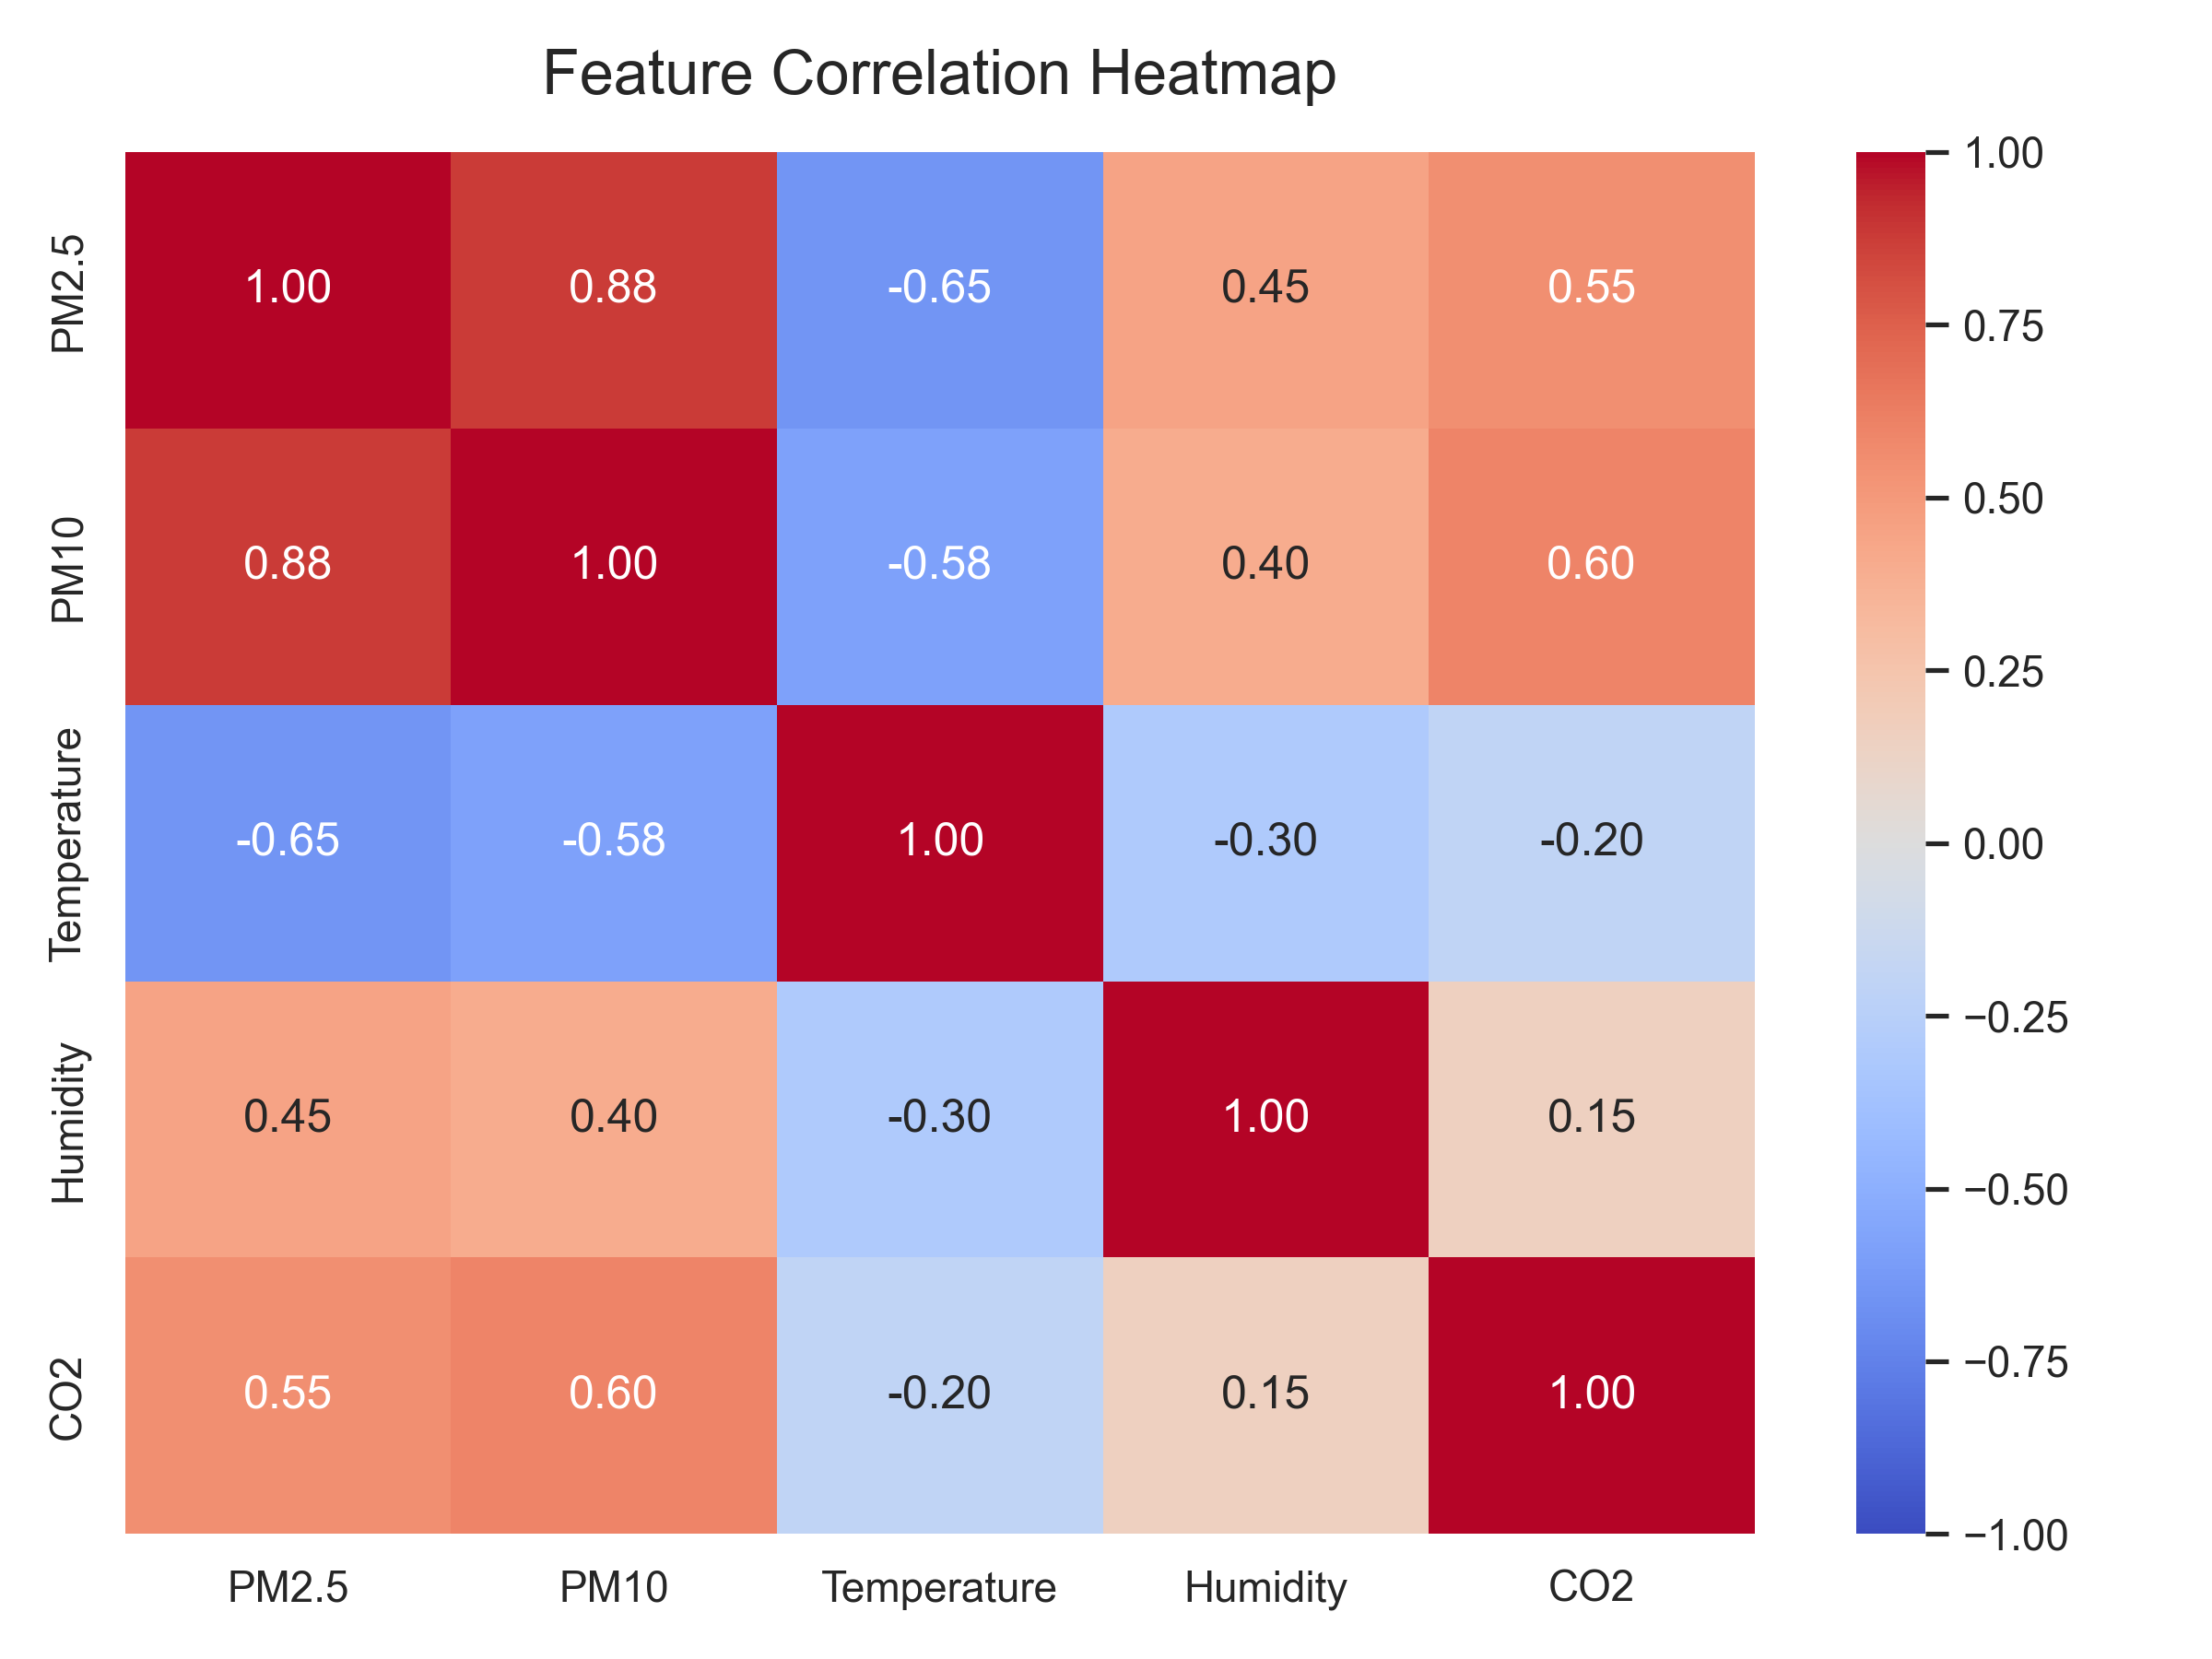

### Risk Thresholds
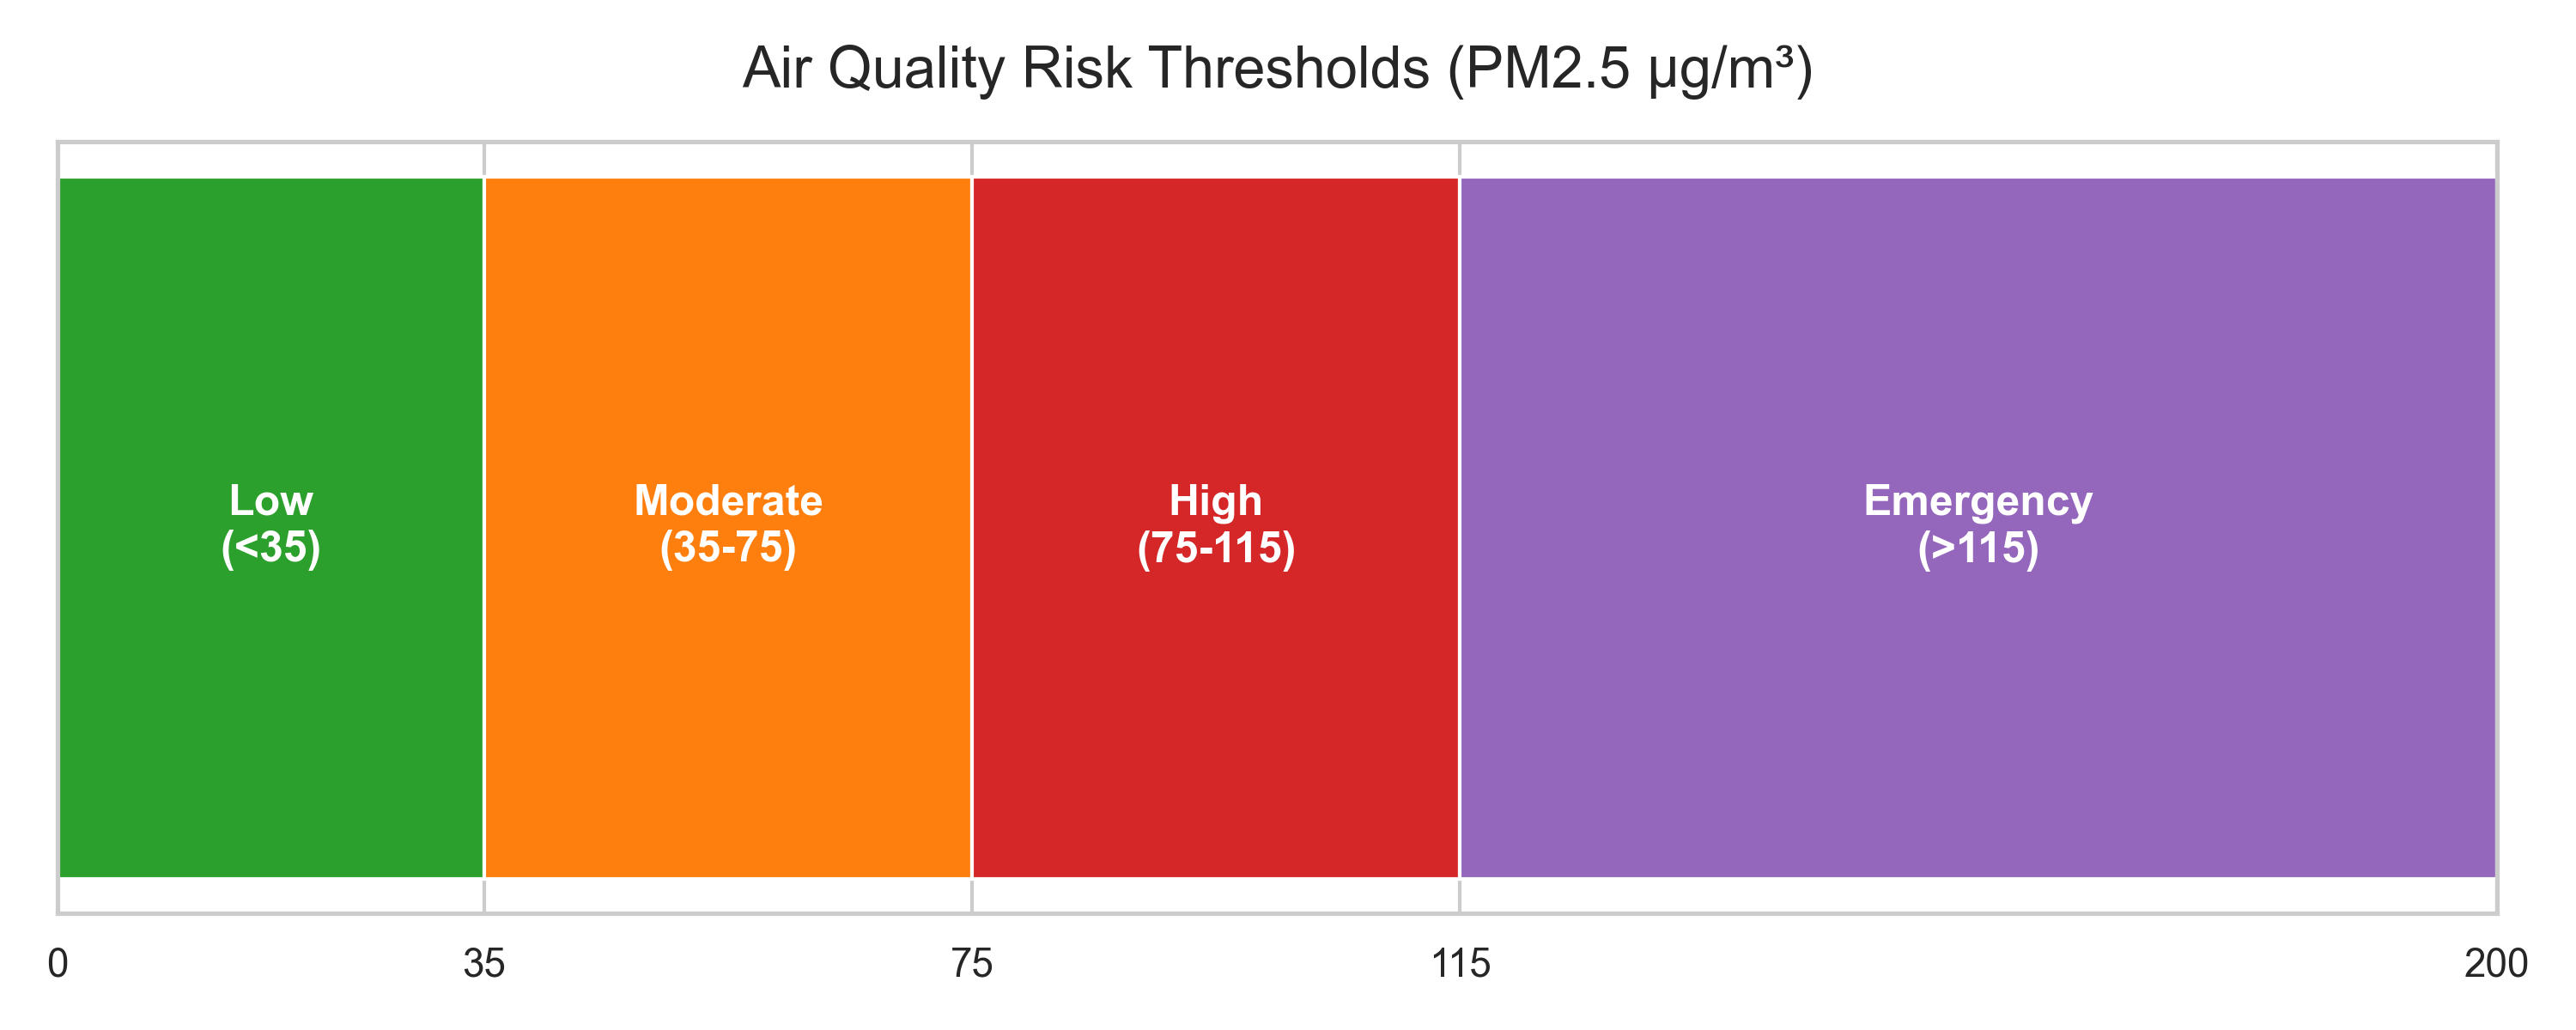

### Health Risk Multipliers
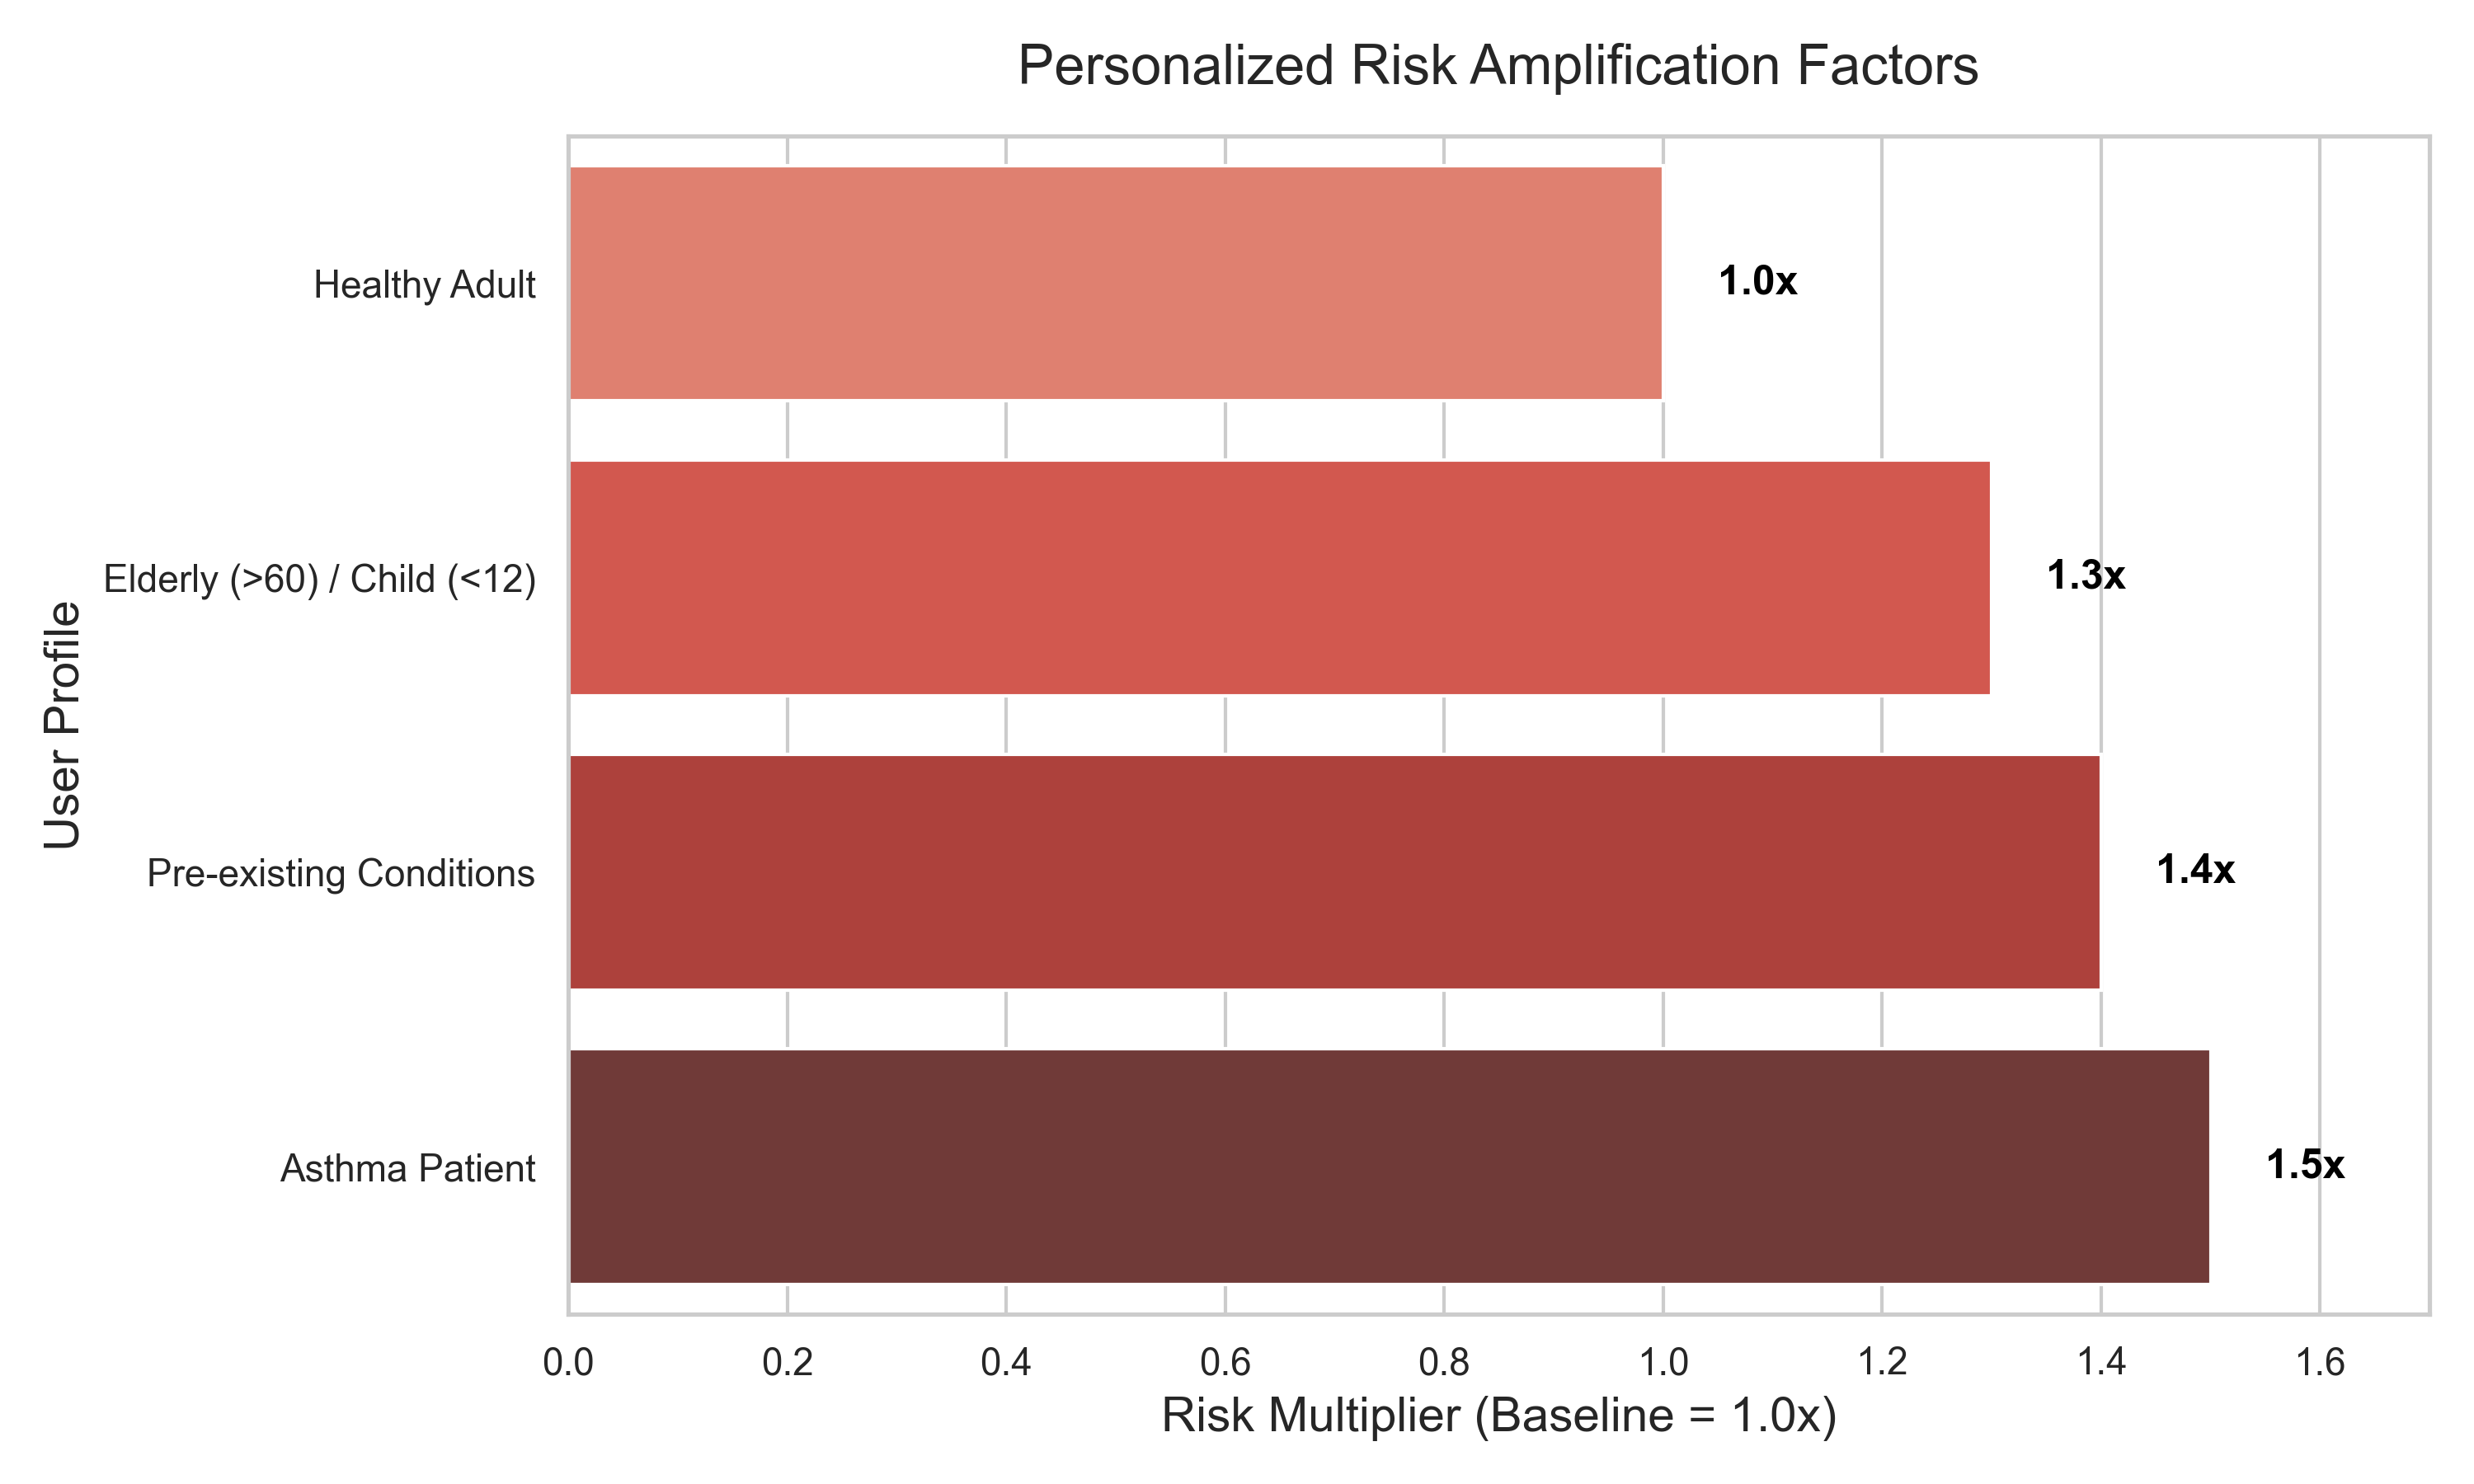